# JWST stellar-field inference

This tutorial builds a compact JWST-like imaging model, simulates a field of stars
with distinct positions, fluxes, and effective temperatures, and jointly recovers
the astrometry and photometry. The pupil geometry is representative rather than a
flight-fidelity WebbPSF replacement; the final section states that boundary clearly.

In [1]:
import equinox as eqx
import jax.numpy as np
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax
import zodiax as zdx
from matplotlib.colors import CenteredNorm, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm.notebook import tqdm

import dLux as dl

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.family": "serif", "image.origin": "lower"})
cmaps = {"intensity": mpl.colormaps["inferno"], "residual": mpl.colormaps["seismic"]}


def colorbar(image, label):
    divider = make_axes_locatable(image.axes)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return image.axes.figure.colorbar(image, cax=cax, label=label)


def update(params, *objects):
    unused, updated = set(params), []
    for obj in objects:
        values = {}
        for path, value in params.items():
            try:
                obj.get(path, to_array=False)
            except AttributeError:
                continue
            values[path] = value
            unused.discard(path)
        updated.append(obj.set(**values))
    if unused:
        print(f"Unused parameters: {sorted(unused)}")
    return tuple(updated)

## Build a compact NIRCam-like model

The wavelength samples span a broad near-infrared band and the focal grid uses a
31 milliarcsecond pixel scale, representative of the NIRCam short-wavelength
channel. `JWSTLike` captures the segmented topology and simplified supports; it
omits measured segment figures, field-dependent aberrations, coatings, and the
calibrated detector response included in observatory simulators.

In [2]:
pupil_grid = dl.GridSpec(n=128, diam=8.0, unit="m")
focal_grid = dl.GridSpec(n=64, d=31, unit="mas")
pupil = dl.JWSTLike(opd=dl.ZernikeDef(nolls=[4, 5, 6], norm=dl.Norm("rms", 20e-9)))
optics = dl.OpticalSystem(
    grid=pupil_grid,
    layers=[("pupil", pupil(pupil_grid, key=jr.key(0))), ("focus", dl.Fraunhofer(focal_grid))],
)

wavelengths = np.linspace(1.5, 2.0, 7)
source = dl.Source(
    wavelengths=wavelengths,
    weights=dl.Blackbody(np.array([4800.0, 6100.0, 7600.0])),
    position=np.array([[-180.0, 90.0], [35.0, -20.0], [210.0, 150.0]]),
    flux=np.array([4.6, 5.0, 4.3]),
    units={"wavelengths": "um", "position": "mas", "flux": "log"},
)
truth_psf = optics.model(source)

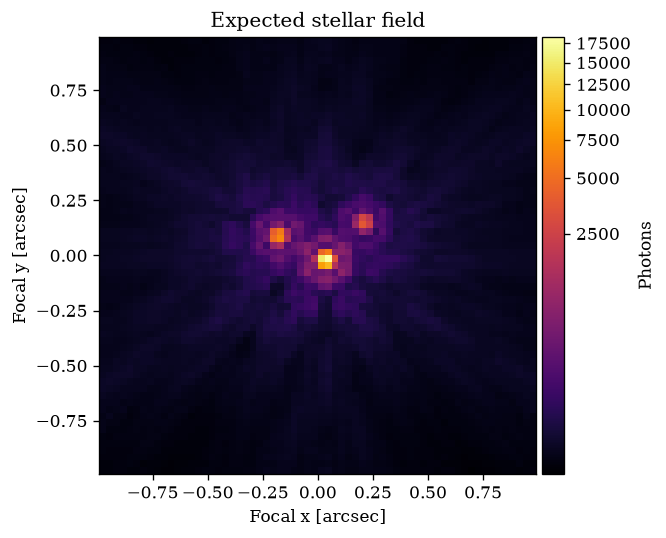

In [3]:
## COLLAPSE: Plotting code
extent = focal_grid.extent(ndim=2, unit="arcsec")
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(truth_psf.data, cmaps["intensity"], extent=extent, norm=PowerNorm(0.3))
ax.set(title="Expected stellar field", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")
plt.show()

## Simulate and initialise the fit

Repeated frames reduce the variance of the mean exposure. In a catalogue pipeline,
correlation with a unit-flux PSF would provide the initial detections; here we use
deliberately offset catalogue guesses so the tutorial remains focused on the joint
differentiable fit rather than source-finding details.

In [4]:
image = dl.Image(truth_psf, read_noise=5.0)
exposure = image.simulate(jr.key(1), n_frames=32)
truth = {"position": source.position, "flux": source.flux, "pupil.coeffs": optics.pupil.coeffs}
params = {
    "position": truth["position"] + np.array([[8.0, -5.0], [-6.0, 7.0], [5.0, 6.0]]),
    "flux": truth["flux"] + np.array([-0.08, 0.06, -0.05]),
    "pupil.coeffs": np.zeros_like(optics.pupil.coeffs),
}


def model_fn(params, optics, source):
    optics, source = update(params, optics, source)
    return optics.model(source)


@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, source, exposure):
    prediction = model_fn(params, optics, source)
    return np.mean(exposure.z_score(prediction) ** 2)


start = model_fn(params, optics, source)

## Recover the catalogue and low-order wavefront

Separate learning rates reflect the different numerical scales of milliarcsecond
positions, logarithmic photon fluxes, and support-normalised OPD coeffs.

In [5]:
optimisers = {
    "position": optax.sgd(0.8, momentum=0.5),
    "flux": optax.sgd(2e-5, momentum=0.5),
    "pupil.coeffs": optax.sgd(1e-3, momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)
losses = []
for _ in tqdm(range(40)):
    loss, grads = loss_fn(params, optics, source, exposure)
    updates, state = optim.update(grads, state)
    params = eqx.apply_updates(params, updates)
    losses.append(loss)
fit = model_fn(params, optics, source)

  0%|          | 0/40 [00:00<?, ?it/s]

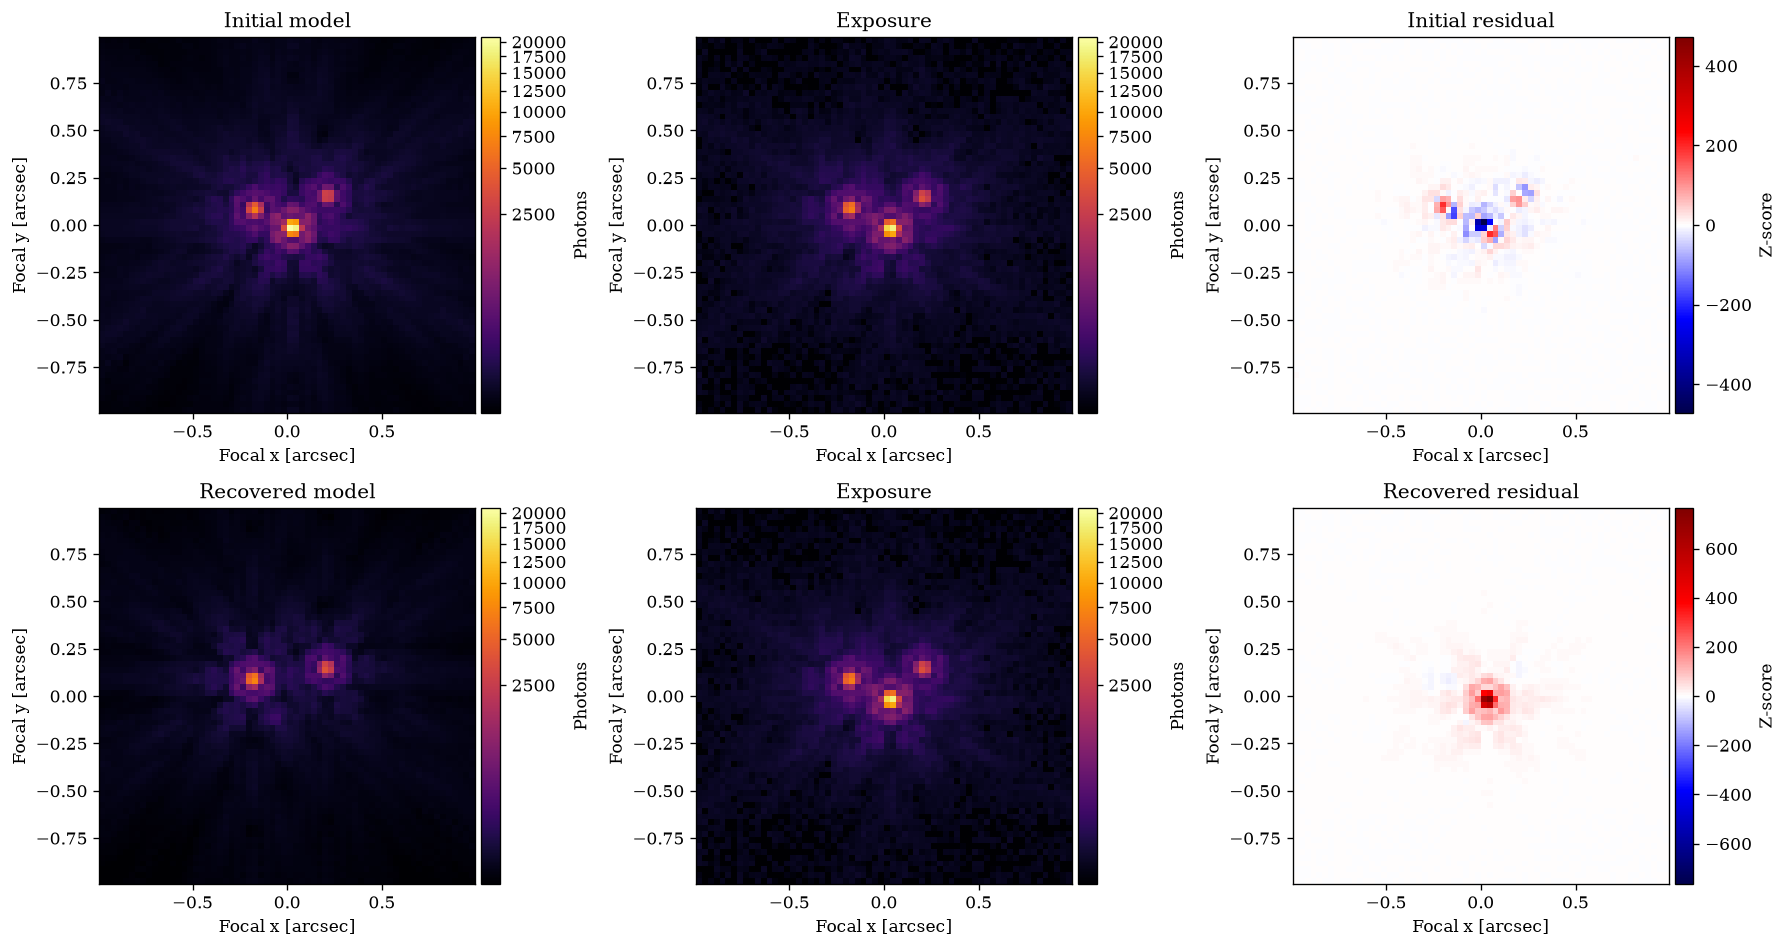

In [6]:
## COLLAPSE: Plotting code
start_z = exposure.z_score(start)
fit_z = exposure.z_score(fit)
norm = PowerNorm(0.3)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (model, residual, label) in enumerate([(start, start_z, "Initial"), (fit, fit_z, "Recovered")]):
    im = axes[row, 0].imshow(model.data, cmaps["intensity"], extent=extent, norm=norm)
    axes[row, 0].set(title=f"{label} model", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    colorbar(im, "Photons")
    im = axes[row, 1].imshow(exposure.data, cmaps["intensity"], extent=extent, norm=norm)
    axes[row, 1].set(title="Exposure", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    colorbar(im, "Photons")
    im = axes[row, 2].imshow(residual, cmaps["residual"], extent=extent, norm=CenteredNorm())
    axes[row, 2].set(title=f"{label} residual", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    colorbar(im, "Z-score")
fig.tight_layout()
plt.show()

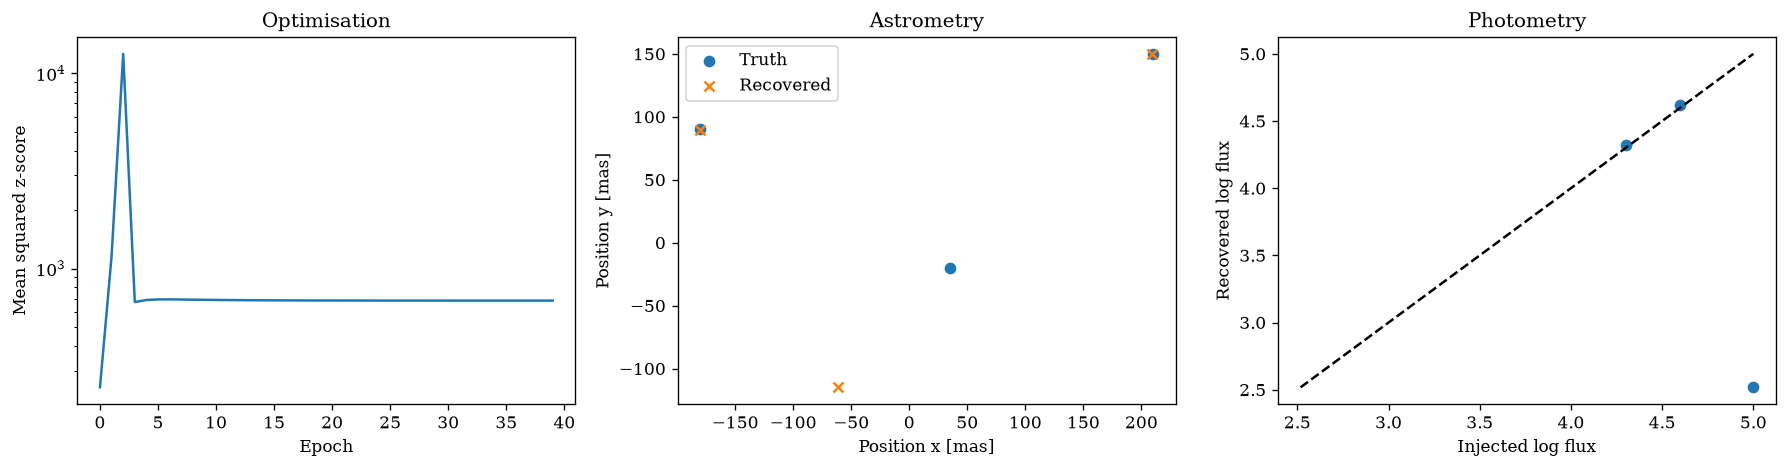

In [7]:
## COLLAPSE: Plotting code
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(losses)
axes[0].set(title="Optimisation", xlabel="Epoch", ylabel="Mean squared z-score", yscale="log")
axes[1].scatter(truth["position"][:, 0], truth["position"][:, 1], label="Truth")
axes[1].scatter(params["position"][:, 0], params["position"][:, 1], marker="x", label="Recovered")
axes[1].set(title="Astrometry", xlabel="Position x [mas]", ylabel="Position y [mas]")
axes[1].legend()
axes[2].scatter(truth["flux"], params["flux"])
limits = np.array([truth["flux"], params["flux"]])
axes[2].plot([limits.min(), limits.max()], [limits.min(), limits.max()], "k--")
axes[2].set(title="Photometry", xlabel="Injected log flux", ylabel="Recovered log flux")
fig.tight_layout()
plt.show()

## Interpretation

A single vectorised `Source` carries the complete stellar field, including one
blackbody spectrum per star, while the nested dLux paths expose the catalogue and
wavefront leaves to Zodiax. This compact model demonstrates the inference contract;
precision NIRCam work should replace the representative pupil and band samples with
calibrated throughput, OPD, distortion, IPC, and detector models and validate the
resulting PSF against WebbPSF or STPSF.